## 7. Hyperparameter Tuning

In this section, we fine-tune the two best-performing models (Logistic Regression and CatBoost) using RandomizedSearchCV to improve their performance further.

In [12]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train = joblib.load("../models/X_train.pkl")
X_test = joblib.load("../models/X_test.pkl")
y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")


### 7.1 Tune Logistic Regression

In [13]:
log_reg_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

log_reg_search = RandomizedSearchCV(
    LogisticRegression(random_state=42, class_weight="balanced"),
    param_distributions=log_reg_params,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

log_reg_search.fit(X_train, y_train)

print("Best Params:", log_reg_search.best_params_)
print("Best ROC-AUC (CV):", log_reg_search.best_score_)

Best Params: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best ROC-AUC (CV): 0.8455609293418991


c:\Churn-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### 7.2 Tune CatBoost

In [14]:
catboost_params = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "iterations": [200, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 7]
}

catboost_search = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, verbose=0, auto_class_weights="Balanced"),
    param_distributions=catboost_params,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

catboost_search.fit(X_train, y_train)

print("Best Params:", catboost_search.best_params_)
print("Best ROC-AUC (CV):", catboost_search.best_score_)

Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 4}
Best ROC-AUC (CV): 0.8492852069016171


### 7.3 Evaluate Tuned Models on Test Set

In [15]:
tuned_models = {
    "Logistic Regression (Tuned)": log_reg_search.best_estimator_,
    "CatBoost (Tuned)": catboost_search.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Tuned),0.738112,0.504318,0.780749,0.612802,0.840262
1,CatBoost (Tuned),0.743790,0.511073,0.802139,0.624350,0.847141


In [16]:
best_model = catboost_search.best_estimator_
joblib.dump(best_model, "../models/final_churn_model.pkl")

['../models/final_churn_model.pkl']

Logistic Regression achieved the highest ROC-AUC (0.842) and Recall (78.3%) among the baseline models, making it the strongest candidate before tuning. Decision Tree performed noticeably worse (ROC-AUC 0.660, Recall 49.2%), showing signs of overfitting without hyperparameter constraints. CatBoost and Random Forest offered the best Precision (~0.53–0.57), but at the cost of lower Recall — a trade-off less suitable for churn prediction, where catching at-risk customers matters more.

### 7.4 Confusion Matrix & ROC Curve (Final Model)

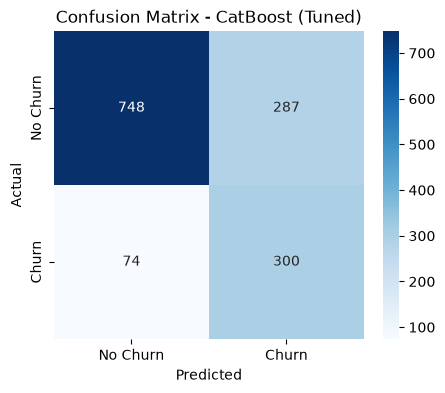

<Figure size 600x500 with 0 Axes>

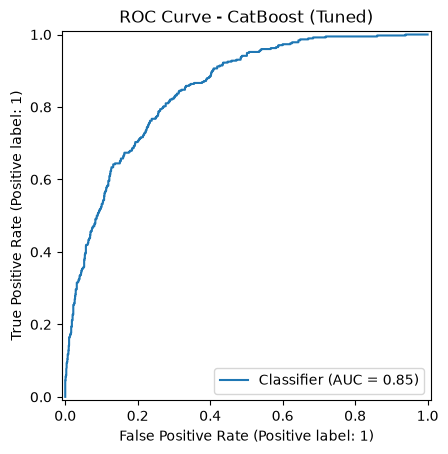

In [17]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost (Tuned)")
plt.show()

# --- ROC Curve ---
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_final)
plt.title("ROC Curve - CatBoost (Tuned)")
plt.show()

## 9. Model Explainability with SHAP

In this section, we use SHAP (SHapley Additive exPlanations) to understand which features drive the model's churn predictions, both globally (across all customers) and for individual cases.

In [18]:
import shap

### 9.1 Create SHAP Explainer

In [19]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

### 9.2 Global Feature Importance (Summary Plot)

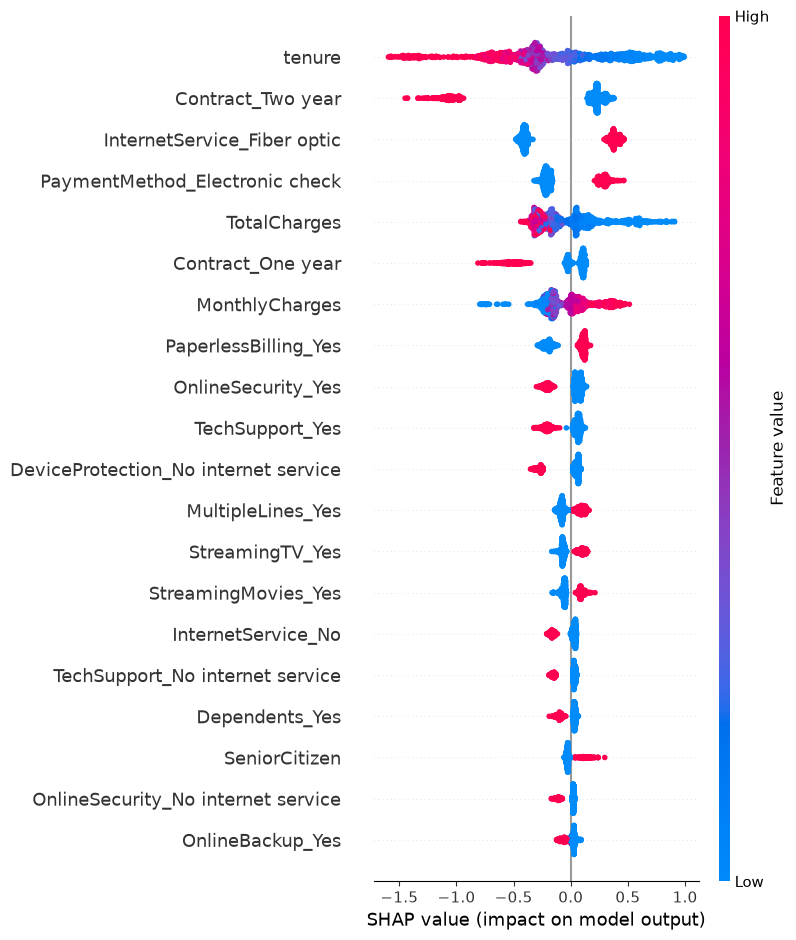

In [20]:
shap.summary_plot(shap_values, X_test)

### 9.3 Explain a Single Prediction

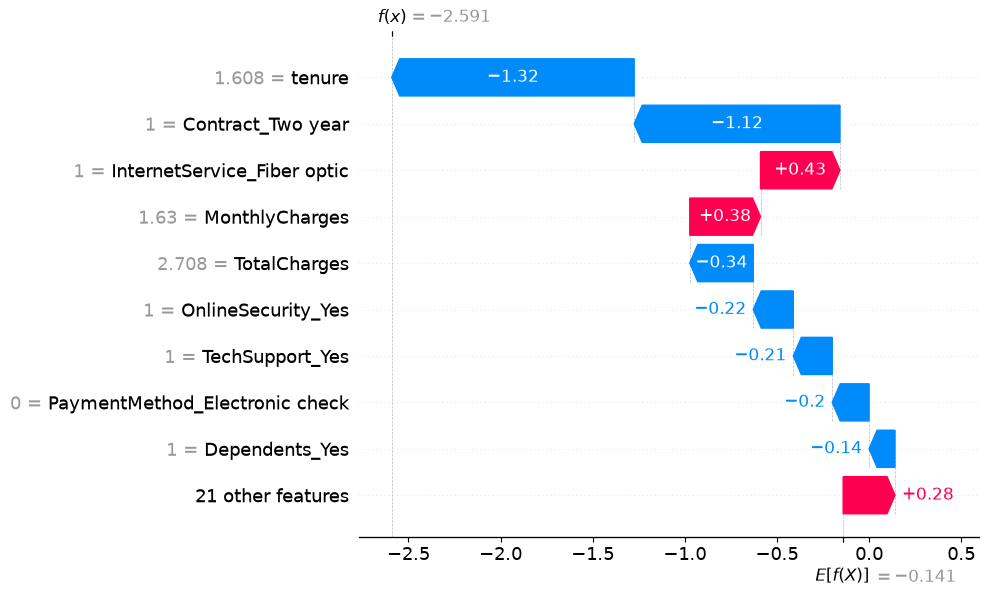

In [24]:
sample_idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=X_test.columns.tolist()
    )
)

### 8. Conclusion

Two candidate models — Logistic Regression and CatBoost — were tuned using RandomizedSearchCV with 5-fold cross-validation, optimizing for ROC-AUC.

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression (Tuned) | 0.738 | 0.504 | 0.781 | 0.613 | 0.840 |
| **CatBoost (Tuned)** | **0.744** | **0.511** | **0.802** | **0.624** | **0.847** |

**Best Model: CatBoost (Tuned)**

CatBoost was selected as the final model because it achieved the highest ROC-AUC (0.847) and the highest Recall (0.802) among all tested models. In a churn prediction context, Recall is prioritized over Accuracy or Precision, since the business cost of missing a customer who will actually churn is higher than the cost of a false alarm. CatBoost tuning parameters: `depth=4`, `learning_rate=0.05`, `iterations=200`, `l2_leaf_reg=5`.

The tuned CatBoost model was saved as `final_churn_model.pkl` for use in the SHAP explainability analysis and the Streamlit deployment app.

In [26]:
import pandas as pd
df_check = pd.read_csv("../cleaned_churn_data.csv")
print(df_check.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
